# BraTS Domain Generalization — Multi-scale Feature Consistency

This notebook extends the ConsistMix idea beyond the logit level.

**Motivation.** MixStyle is inserted at `layer2`. The resulting feature
perturbation propagates through `layer3`, `layer4`, and the pre-FC
representation before it becomes a logit. The original ConsistMix only
penalises disagreement at the very end (output-level KL). The hypothesis
tested here is that *feature-space* consistency — a cosine distance
between the clean and mixed representations at each stage — captures
the mechanism more directly and is what actually drives the gain.

**Four experiments.** All use layer-2 training only, trained for 15 epochs
on the same split (site 18 held out).

1. `Baseline-L2` — ERM, no MixStyle.
2. `MixStyle-L2-p0.5-a0.5` — plain MixStyle, no consistency.
3. `ConsistMix-L2-p0.5-a0.5-lam2.0` — existing output-level KL version.
4. `ConsistMixMulti-L2-p0.5-a0.5-cos` — per-layer cosine consistency
   at `layer2`, `layer3`, `layer4`, and the pre-FC features (no logit KL),
   to isolate the multi-scale signal.


## Setup

In [1]:
import importlib.util
import subprocess
import sys

required = {
    "synapseclient": "synapseclient",
    "nibabel": "nibabel",
    "pandas": "pandas",
    "openpyxl": "openpyxl",
    "PIL": "pillow",
    "matplotlib": "matplotlib",
    "torch": "torch",
    "torchvision": "torchvision",
}

missing = [pkg for module_name, pkg in required.items() if importlib.util.find_spec(module_name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    raise RuntimeError(
        "Installed missing packages. Restart the kernel, then rerun the notebook from the top."
    )
print("All required packages already available.")


All required packages already available.


In [2]:
from pathlib import Path
import pandas as pd
from IPython.display import display

from dg import config, runtime
from dg.splits import build_main_split, summarize_split
from dg.experiment import (
    DataSplitConfig,
    ModelConfig,
    compare_models,
    prepare_dataloaders_from_config,
    report_experiments,
    run_experiment,
)
from dg.training import set_seed

set_seed(config.EXP_SEED)
print("device =", runtime.DEVICE)


device = cuda


## Load the preprocessed index

Reads `brats23_npz_dg/index.csv` and verifies every listed `.npz` is
actually on disk. If the index is missing **or** any cases are gone
(e.g. the directory was partially cleaned), this cell re-runs
`preprocess_zip_to_npz()` from the BraTS ZIP to regenerate them.

*Requires* `config.ZIP_PATH` to point at the downloaded BraTS ZIP. If
you have not downloaded it yet, run the Synapse download step from
`final_report.ipynb` first.


In [3]:
from dg.preprocessing import preprocess_zip_to_npz

index_path = Path(config.OUT_ROOT) / "index.csv"

def _scan_index(df: pd.DataFrame):
    exists = df["npz_path"].apply(lambda p: Path(p).exists())
    return int(exists.sum()), int((~exists).sum())

def _load_and_check():
    if not index_path.exists():
        return None, None, None
    df = pd.read_csv(index_path)
    present, missing = _scan_index(df)
    return df, present, missing

index_df, present, missing = _load_and_check()
needs_preprocess = index_df is None or missing > 0

if needs_preprocess:
    if index_df is None:
        print("No index.csv — running preprocess_zip_to_npz() from the ZIP.")
    else:
        print(f"Stale dataset: {present}/{present+missing} files present; {missing} missing.")
        print("Re-running preprocess_zip_to_npz() to regenerate missing cases from the ZIP.")
    # Requires config.ZIP_PATH to point at the BraTS ZIP. If you have not
    # downloaded it yet, run the download step from final_report.ipynb first.
    index_df = preprocess_zip_to_npz()
    index_df, present, missing = _load_and_check()
    assert index_df is not None and missing == 0, (
        f"Preprocessing did not close the gap — {missing} rows still missing. "
        "Check config.ZIP_PATH and disk space, then re-run this cell."
    )

print("sites:", sorted(index_df["site"].unique().tolist()))
print("cases:", index_df["case_id"].nunique(), "slices:", len(index_df))
print("files on disk:", present)


sites: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
cases: 1251 slices: 1251
files on disk: 1251


## Main split: hold out site 18

Same held-out site as `final_report.ipynb` so results are comparable.

In [4]:
TEST_SITES = [18]
split = build_main_split(index_df, test_sites=TEST_SITES)

summarize_split("train", split["train_df"])
summarize_split("val", split["val_df"])
summarize_split("in-domain test", split["in_domain_test_df"])
summarize_split("out-domain test", split["out_domain_test_df"])

default_data_config = DataSplitConfig(
    name="default",
    train_cases=frozenset(split["train_set"]),
    validation_cases=frozenset(split["val_set"]),
    test_cases=frozenset(split["in_domain_test_set"]),
    out_domain_test_cases=frozenset(split["out_domain_test_set"]),
)



train
cases=296, slices=23559, tumor=11737, normal=11822, tumor_ratio=0.4982
top sites by cases:
site
1     44
4     33
21    25
13    25
6     24
20    23
16    22
5     16
3     11
11    10
Name: case_id, dtype: int64

val
cases=63, slices=5011, tumor=2491, normal=2520, tumor_ratio=0.4971
top sites by cases:
site
1     10
4      7
6      5
20     5
21     5
13     5
16     4
5      3
15     2
3      2
Name: case_id, dtype: int64

in-domain test
cases=63, slices=5018, tumor=2517, normal=2501, tumor_ratio=0.5016
top sites by cases:
site
1     10
4      7
6      5
20     5
21     5
13     5
16     4
5      3
15     2
3      2
Name: case_id, dtype: int64

out-domain test
cases=382, slices=30232, tumor=14980, normal=15252, tumor_ratio=0.4955
top sites by cases:
site
18    382
Name: case_id, dtype: int64


## Define the four experiments

- `multiscale_layer_weights` is a tuple of `(stage_name, weight)` pairs.
  Stages available: `layer1`, `layer2`, `layer3`, `layer4`, `feats`.
- `multiscale_distance="cosine"` uses `1 - cos(f_mixed, f_clean)` on GAP'd
  features. Scale-invariant, so the mixed branch is only penalised for
  *direction* drift — magnitude can still move.
- The clean branch is a stop-gradient teacher at every scale (enforced
  inside the training loop).


In [25]:
baseline_cfg = ModelConfig(
    name="Baseline-L2-rerun",
    train_layers=(2,),
    use_mixstyle=False,
)

mixstyle_cfg = ModelConfig(
    name="MixStyle-L2-p0.5-a0.5-rerun",
    train_layers=(2,),
    use_mixstyle=True,
    mixstyle_p=0.5,
    mixstyle_a=0.5,
)

consist_cfg = ModelConfig(
    name="ConsistMix-L2-p0.5-a0.5-lam1.0",
    train_layers=(2,),
    use_mixstyle=True,
    mixstyle_p=0.5,
    mixstyle_a=0.5,
    consistency_lambda=1.0,
)

multi_cfg = ModelConfig(
    name="ConsistMixMulti-L2-p0.5-a0.5-cos",
    train_layers=(2,),
    use_mixstyle=True,
    mixstyle_p=0.5,
    mixstyle_a=0.5,
    multiscale_layer_weights=(
        ("layer2", 1.0),
        ("layer3", 1.0),
        ("layer4", 1.0),
        ("feats",  1.0),
    ),
    multiscale_distance="cosine",
    multiscale_logit_kl_lambda=0.0,
)
# experiments = [consist_cfg]

experiments = [baseline_cfg, mixstyle_cfg, consist_cfg, multi_cfg]
for cfg in experiments:
    print(cfg.name)


Baseline-L2-rerun
MixStyle-L2-p0.5-a0.5-rerun
ConsistMix-L2-p0.5-a0.5-lam1.0
ConsistMixMulti-L2-p0.5-a0.5-cos


## Train all four

Trains sequentially, 15 epochs each, early-stopping on validation
accuracy. Results are saved to `artifacts/results/<name>.json` and
checkpoints to `artifacts/checkpoints/best_<name>.pth`.

In [22]:
results = []
for cfg in experiments:
    print(f"\n{'='*72}\n>>> {cfg.name}\n{'='*72}")
    r = run_experiment(cfg, default_data_config, index_df=index_df, epochs=15)
    results.append(r)

results_by_name = {r["name"]: r for r in results}



>>> MixStyle-L2-p0.75-a0.1-rerun


KeyboardInterrupt: 

## Report all four side by side

In [26]:
loaders = prepare_dataloaders_from_config(default_data_config, index_df=index_df, verbose=False)
report_experiments(experiments, loaders, results_by_name=results_by_name)


=== Report ===

Baseline-L2-rerun | Layer: (2,) MixStyle: False (p=0.5, a=0.1) | Val: 0.9176
  In-domain Acc: 0.8988 | Out-domain Acc: 0.8398 | In-domain Bal Acc: 0.8988 | Out-domain Bal Acc: 0.8406
  tumor P/R/F1 in-domain: 0.8981/0.9003/0.8992 | out-domain: 0.7897/0.9224/0.8509
MixStyle-L2-p0.5-a0.5-rerun | Layer: (2,) MixStyle: True (p=0.5, a=0.5) | Val: 0.9096
  In-domain Acc: 0.9259 | Out-domain Acc: 0.8998 | In-domain Bal Acc: 0.9260 | Out-domain Bal Acc: 0.8995
  tumor P/R/F1 in-domain: 0.9566/0.8927/0.9236 | out-domain: 0.9196/0.8742/0.8963
ConsistMix-L2-p0.5-a0.5-lam1.0 | Layer: (2,) MixStyle: True (p=0.5, a=0.5) | Val: 0.9112
  In-domain Acc: 0.9229 | Out-domain Acc: 0.8964 | In-domain Bal Acc: 0.9229 | Out-domain Bal Acc: 0.8965
  tumor P/R/F1 in-domain: 0.9301/0.9150/0.9225 | out-domain: 0.8902/0.9023/0.8962
ConsistMixMulti-L2-p0.5-a0.5-cos | Layer: (2,) MixStyle: True (p=0.5, a=0.5) | Val: 0.9122
  In-domain Acc: 0.9173 | Out-domain Acc: 0.9008 | In-domain Bal Acc: 0.9174 

[(ModelConfig(name='Baseline-L2-rerun', train_layers=(2,), use_mixstyle=False, mixstyle_p=0.5, mixstyle_a=0.1, consistency_lambda=0.0, multiscale_layer_weights=(), multiscale_distance='cosine', multiscale_logit_kl_lambda=0.0, mmd_lambda=0.0, mmd_class_conditional=True, mmd_sigma_list=(1.0, 5.0, 10.0), mmd_max_samples=256),
  0.9175813210935941,
  {'accuracy': 0.8987644479872459,
   'balanced_accuracy': 0.8987596062091652,
   'tumor_precision': 0.8981371383273881,
   'tumor_recall': 0.9002781088597537,
   'tumor_f1': 0.8992063492063492,
   'tp': 2266,
   'fp': 257,
   'tn': 2244,
   'fn': 251},
  {'accuracy': 0.8398385816353533,
   'balanced_accuracy': 0.8405750371944478,
   'tumor_precision': 0.7896902503143216,
   'tumor_recall': 0.922429906542056,
   'tumor_f1': 0.850914465176427,
   'tp': 13818,
   'fp': 3680,
   'tn': 11572,
   'fn': 1162}),
 (ModelConfig(name='MixStyle-L2-p0.5-a0.5-rerun', train_layers=(2,), use_mixstyle=True, mixstyle_p=0.5, mixstyle_a=0.5, consistency_lambda=0.0

## Pairwise deltas

- **Plain MixStyle vs. Baseline** — baseline gain from style mixing alone.
- **ConsistMix (logit KL) vs. MixStyle** — what output-level consistency adds.
- **Multi-scale vs. ConsistMix** — what per-layer feature-space
  consistency adds on top of output-level KL. A positive delta here is
  the main experimental claim for this notebook.


In [29]:
print("\n--- MixStyle vs Baseline ---")
compare_models([baseline_cfg, mixstyle_cfg], loaders)

print("\n--- ConsistMix (logit KL) vs MixStyle ---")
compare_models([mixstyle_cfg, consist_cfg], loaders)

print("\n--- Multi-scale (feature cosine) vs ConsistMix (logit KL) ---")
compare_models([consist_cfg, multi_cfg], loaders)

print("\n--- Multi-scale vs Baseline (overall gain from the full chain) ---")
compare_models([baseline_cfg, multi_cfg], loaders)



--- MixStyle vs Baseline ---
Baseline-L2-rerun
  in-domain  acc=0.8988 bal_acc=0.8988 tumor_f1=0.8992
  out-domain acc=0.8398 bal_acc=0.8406 tumor_f1=0.8509
MixStyle-L2-p0.5-a0.5-rerun
  in-domain  acc=0.9259 bal_acc=0.9260 tumor_f1=0.9236
  out-domain acc=0.8998 bal_acc=0.8995 tumor_f1=0.8963

Comparison
baseline: Baseline-L2-rerun
compare:  MixStyle-L2-p0.5-a0.5-rerun
delta in_acc:       +0.0271
delta in_bal_acc:   +0.0272
delta out_acc:      +0.0599
delta out_bal_acc:  +0.0590
delta out_tumor_f1: +0.0454
out_accuracy improvement: +7.14%

--- ConsistMix (logit KL) vs MixStyle ---
MixStyle-L2-p0.5-a0.5-rerun
  in-domain  acc=0.9259 bal_acc=0.9260 tumor_f1=0.9236
  out-domain acc=0.8998 bal_acc=0.8995 tumor_f1=0.8963
ConsistMix-L2-p0.5-a0.5-lam1.0
  in-domain  acc=0.9229 bal_acc=0.9229 tumor_f1=0.9225
  out-domain acc=0.8964 bal_acc=0.8965 tumor_f1=0.8962

Comparison
baseline: MixStyle-L2-p0.5-a0.5-rerun
compare:  ConsistMix-L2-p0.5-a0.5-lam1.0
delta in_acc:       -0.0030
delta in_bal

[(ModelConfig(name='Baseline-L2-rerun', train_layers=(2,), use_mixstyle=False, mixstyle_p=0.5, mixstyle_a=0.1, consistency_lambda=0.0, multiscale_layer_weights=(), multiscale_distance='cosine', multiscale_logit_kl_lambda=0.0, mmd_lambda=0.0, mmd_class_conditional=True, mmd_sigma_list=(1.0, 5.0, 10.0), mmd_max_samples=256),
  {'accuracy': 0.8987644479872459,
   'balanced_accuracy': 0.8987596062091652,
   'tumor_precision': 0.8981371383273881,
   'tumor_recall': 0.9002781088597537,
   'tumor_f1': 0.8992063492063492,
   'tp': 2266,
   'fp': 257,
   'tn': 2244,
   'fn': 251},
  {'accuracy': 0.8398385816353533,
   'balanced_accuracy': 0.8405750371944478,
   'tumor_precision': 0.7896902503143216,
   'tumor_recall': 0.922429906542056,
   'tumor_f1': 0.850914465176427,
   'tp': 13818,
   'fp': 3680,
   'tn': 11572,
   'fn': 1162}),
 (ModelConfig(name='ConsistMixMulti-L2-p0.5-a0.5-cos', train_layers=(2,), use_mixstyle=True, mixstyle_p=0.5, mixstyle_a=0.5, consistency_lambda=0.0, multiscale_laye

## Training curves

Sanity check: the multi-scale feature loss should be non-trivial through
training. If it collapses to zero or diverges, re-tune the per-stage
weights.

C:\Users\34783\AppData\Local\Temp\ipykernel_14880\3048596661.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].set_title("Validation accuracy"); axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=8)


KeyError: 'ConsistMixMulti-L2-p0.5-a0.5-cos'

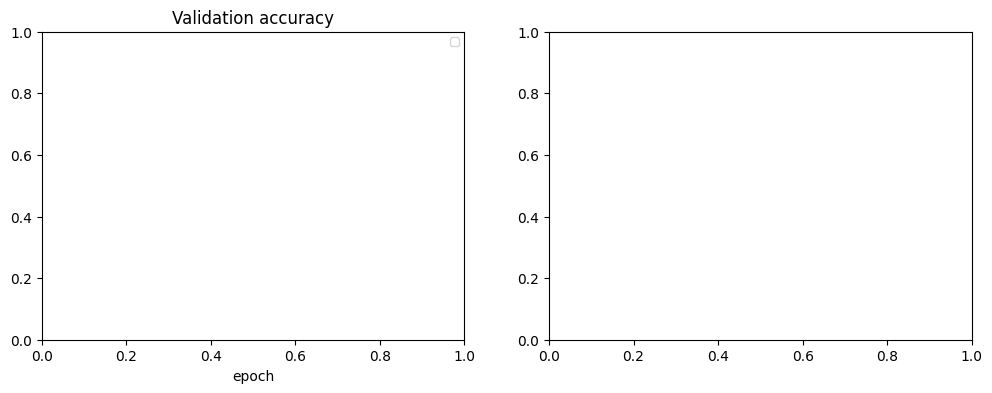

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for r in results:
    epochs = [h["epoch"] for h in r["history"]]
    val = [h["val_acc"] for h in r["history"]]
    axes[0].plot(epochs, val, marker="o", label=r["name"])
axes[0].set_title("Validation accuracy"); axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=8)

multi_hist = results_by_name[multi_cfg.name]["history"]
epochs = [h["epoch"] for h in multi_hist]
axes[1].plot(epochs, [h["ce_loss"] for h in multi_hist], marker="o", label="CE")
axes[1].plot(epochs, [h["feat_loss"] for h in multi_hist], marker="o", label="feat (multi-scale cos)")
axes[1].set_title(f"Loss components — {multi_cfg.name}"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()


## Final summary table

In [ ]:
summary_rows = []
for cfg, r in zip(experiments, results):
    ms_w = dict(cfg.multiscale_layer_weights) if cfg.multiscale_layer_weights else {}
    summary_rows.append({
        "name": cfg.name,
        "mixstyle": cfg.use_mixstyle,
        "consistency_lambda": cfg.consistency_lambda,
        "multiscale_stages": ",".join(ms_w.keys()) if ms_w else "",
        "multiscale_distance": cfg.multiscale_distance if ms_w else "",
        "best_val": r["best_val"],
        "in_acc": r["in_domain_test_acc"],
        "out_acc": r["out_domain_test_acc"],
    })
summary = pd.DataFrame(summary_rows)
display(summary)


,name,mixstyle,consistency_lambda,multiscale_stages,multiscale_distance,best_val,in_acc,out_acc
0,Baseline-L2-rerun,False,0.0,,,0.917581,0.919091,0.892134
1,MixStyle-L2-p0.5-a0.5-rerun,True,0.0,,,0.909599,0.925867,0.899775
2,ConsistMix-L2-p0.5-a0.5-lam2.0,True,2.0,,,0.909599,0.917298,0.883898
3,ConsistMixMulti-L2-p0.5-a0.5-cos,True,0.0,"layer2,layer3,layer4,feats",cosine,0.912193,0.917298,0.900834
